In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :png
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
m, k = 250, 10^4
ccrit = 2 * sqrt(m * k)

3162.2776601683795

In [3]:
using SymPyPythonCall
@syms λ
[solve(m * λ^2 + c * λ + k, λ) for c in (1000, ccrit, 6000)]

3-element Vector{Vector{Sym{PythonCall.Py}}}:
 [-2 - 6*I, -2 + 6*I]
 [-6.32455545033384, -6.32455519033968]
 [-12 - 2*sqrt(26), -12 + 2*sqrt(26)]

In [4]:
@syms t y()
soluciones = Dict()
for c in (1000, round(ccrit), 6000)
    eq = Eq(m * diff(y(t), t, 2) + c * diff(y(t), t) + k * y(t), 0)
    sol = dsolve(eq, y(t), ics = Dict(y(0) => Sym(1)/10,
                                      diff(y(t), t)(0) => 0))
    soluciones[c] = rhs(sol)
end
soluciones[1000]

⎛sin(6⋅t)   cos(6⋅t)⎞  -2⋅t
⎜──────── + ────────⎟⋅ℯ    
⎝   30         10   ⎠      

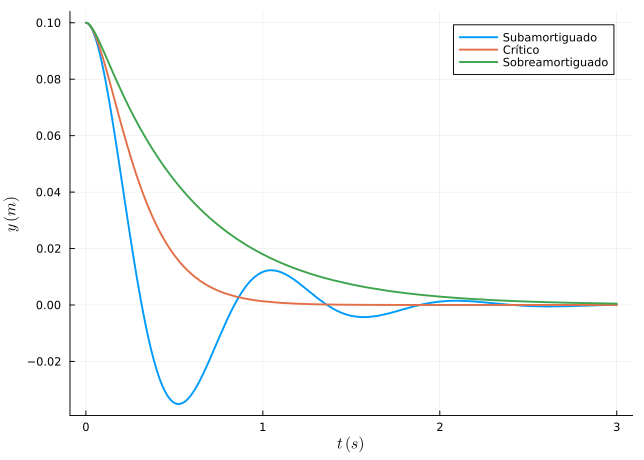

In [5]:
using Plots, LaTeXStrings
plt = plot(xlab = L"t \; (s)", ylab = L"y \; (m)")
etiquetas = Dict(1000 => "Subamortiguado", round(ccrit) => "Crítico",
                 6000 => "Sobreamortiguado")
for (c, expr) in sort(collect(soluciones), by = first)
    plot!(plt, lambdify(expr, (t,)), 0, 3, lw = 2, label = etiquetas[c])
end
plt

In [6]:
using SymPyPythonCall
@syms t ω::positive a b
β, ω0, F0 = Sym(3)/10, 6, 1
yp = a * cos(ω * t) + b * sin(ω * t)
resto = expand(diff(yp, t, 2) + 2β * diff(yp, t) + ω0^2 * yp - F0 * cos(ω * t))
coefs = solve([resto.coeff(cos(ω * t)), resto.coeff(sin(ω * t))], [a, b])
R = simplify(sqrt(coefs[a]^2 + coefs[b]^2))

     _________________________
    ╱     4         2         
5⋅╲╱  25⋅ω  - 1791⋅ω  + 32400 
──────────────────────────────
  │    4         2        │   
  │25⋅ω  - 1791⋅ω  + 32400│   

In [7]:
using Plots, LaTeXStrings
Rnum = lambdify(R, (ω,))
plot(Rnum, 0.01, 12, lw = 2, label = L"R(\omega)",
    xlab = L"\omega \; (rad/s)", ylab = "Amplitud (m)")
ωres = sqrt(36 - 2 * 0.3^2)
vline!([ωres], ls = :dash, label = "Resonancia")
(ω_resonancia = ωres, amplificación = Rnum(ωres) / Rnum(0.01))

(ω_resonancia = 5.984981202978001, amplificación = 10.01249581293317)

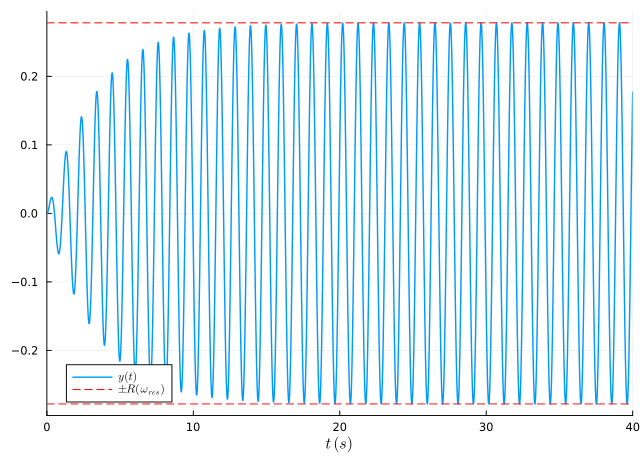

In [8]:
using DifferentialEquations
function pasarela!(du, u, p, t)
    du[1] = u[2]
    du[2] = -2 * 0.3 * u[2] - 36 * u[1] + cos(ωres * t)
end
sol = solve(ODEProblem(pasarela!, [0.0, 0.0], (0.0, 40.0)), saveat = 0.02)
plot(sol, idxs = 1, lw = 1.5, label = L"y(t)", xlab = L"t\;(s)")
hline!([Rnum(ωres), -Rnum(ωres)], ls = :dash, color = :red,
       label = L"\pm R(\omega_{res})")

In [9]:
using SymPyPythonCall
@syms t q()
eq = Eq(diff(q(t), t, 2) + 2diff(q(t), t) + 4q(t), 50cos(t))
sol = dsolve(eq, q(t), ics = Dict(q(0) => 0, diff(q(t), t)(0) => 0))
qsol = expand(simplify(rhs(sol)))

                                  -t                  -t          
100⋅sin(t)   150⋅cos(t)   250⋅√3⋅ℯ  ⋅sin(√3⋅t)   150⋅ℯ  ⋅cos(√3⋅t)
────────── + ────────── - ──────────────────── - ─────────────────
    13           13                39                   13        

In [10]:
qp = Sym(150)/13 * cos(t) + Sym(100)/13 * sin(t)
ip = diff(qp, t)
amplitud = sqrt(ip.coeff(cos(t))^2 + ip.coeff(sin(t))^2) |> simplify

50⋅√13
──────
  13  

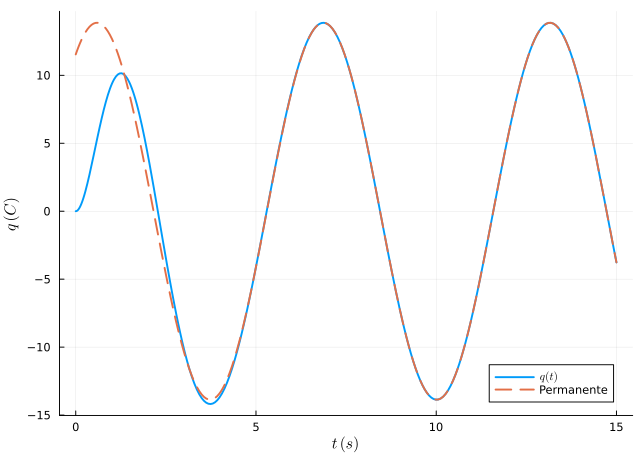

In [11]:
using Plots, LaTeXStrings
plot(lambdify(rhs(sol), (t,)), 0, 15, lw = 2, label = L"q(t)")
plot!(lambdify(qp, (t,)), 0, 15, ls = :dash, lw = 2, label = "Permanente",
      xlab = L"t \; (s)", ylab = L"q \; (C)")

In [12]:
using SymPyPythonCall
@syms x y() C1 C2 C3 C4
EI, w, L = Sym(2 * 10^6), 5000, 4
sol = dsolve(Eq(EI * diff(y(x), x, 4), w), y(x))
yg = rhs(sol)

                              4 
                2       3    x  
C₁ + C₂⋅x + C₃⋅x  + C₄⋅x  + ────
                            9600

In [13]:
consts = free_symbols(yg - w/(24EI) * x^4)   # Las cuatro constantes
condiciones = [yg(x => 0), yg(x => L),
               diff(yg, x, 2)(x => 0), diff(yg, x, 2)(x => L)]
csol = solve(condiciones, consts)
ydef = simplify(yg.subs(csol))

  ⎛ 3      2     ⎞
x⋅⎝x  - 8⋅x  + 64⎠
──────────────────
       9600       

In [14]:
flecha = ydef(x => L/2)
formula = 5 * w * L^4 / (384 * EI)
(flecha_calculada = N(flecha), formula_clasica = N(formula))

(flecha_calculada = 0.008333333333333333, formula_clasica = 1//120)

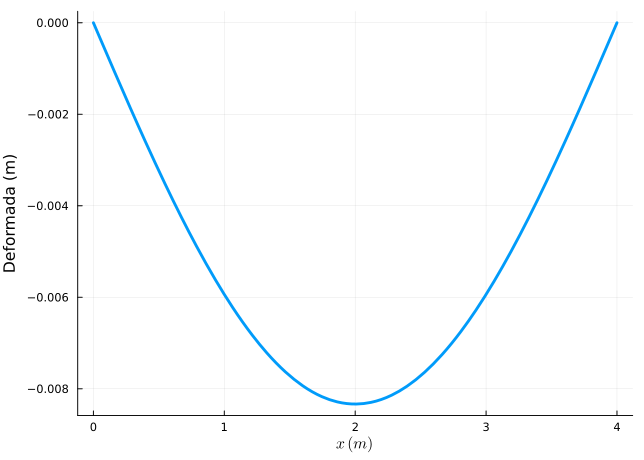

In [15]:
using Plots, LaTeXStrings
plot(lambdify(-ydef, (x,)), 0, 4, lw = 3, legend = false,
    xlab = L"x \; (m)", ylab = "Deformada (m)", yflip = false)

In [16]:
using LinearAlgebra
A = [0 1.0; -36 -0.6]
eigvals(A)

2-element Vector{ComplexF64}:
 -0.3 - 5.992495306631454im
 -0.3 + 5.992495306631454im

In [17]:
@syms λ
solve(λ^2 + Sym(6)/10 * λ + 36, λ)

2-element Vector{Sym{PythonCall.Py}}:
 -3/10 - 3*sqrt(399)*I/10
 -3/10 + 3*sqrt(399)*I/10